# Flickr8k Dataset Exploration

## Internship Day 2

### Objectives
- Explore the Flickr8k dataset
- Calculate dataset statistics
- Analyze caption lengths
- Calculate vocabulary size
- Display sample images with captions
- Identify data quality issues

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

plt.style.use("ggplot")

In [8]:
import os

dataset_path = r"C:\Users\Lenovo\Internship\data\Flickr8k"

image_folder = os.path.join(dataset_path, "images")
caption_file = os.path.join(dataset_path, "captions.txt")

In [9]:
captions = pd.read_csv(caption_file)

captions.head()

ParserError: Error tokenizing data. C error: Expected 1 fields in line 37, saw 2


In [11]:
captions = pd.read_csv(caption_file, sep="|")

captions.head()

,image_name,caption_number,caption_text
0,1000268201_693b08cb0e.jpg,0,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,1,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,2,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,3,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,4,A little girl in a pink dress going into a woo...


In [16]:
print(captions.columns)

Index(['image_name', 'caption_number', 'caption_text'], dtype='str')


In [17]:
captions.head()

,image_name,caption_number,caption_text
0,1000268201_693b08cb0e.jpg,0,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,1,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,2,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,3,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,4,A little girl in a pink dress going into a woo...


In [18]:
# Dataset Statistics

num_images = captions["image_name"].nunique()
num_captions = len(captions)
captions_per_image = num_captions / num_images

print(f"Total Images: {num_images}")
print(f"Total Captions: {num_captions}")
print(f"Average Captions per Image: {captions_per_image:.2f}")

Total Images: 8091
Total Captions: 40455
Average Captions per Image: 5.00


In [19]:
captions["caption_length"] = captions["caption_text"].apply(
    lambda x: len(str(x).split())
)

captions[["caption_text", "caption_length"]].head()

,caption_text,caption_length
0,A child in a pink dress is climbing up a set o...,18
1,A girl going into a wooden building .,8
2,A little girl climbing into a wooden playhouse .,9
3,A little girl climbing the stairs to her playh...,10
4,A little girl in a pink dress going into a woo...,13


In [20]:
captions["caption_length"].describe()

count    40455.000000
mean        11.782598
std          3.885152
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         38.000000
Name: caption_length, dtype: float64

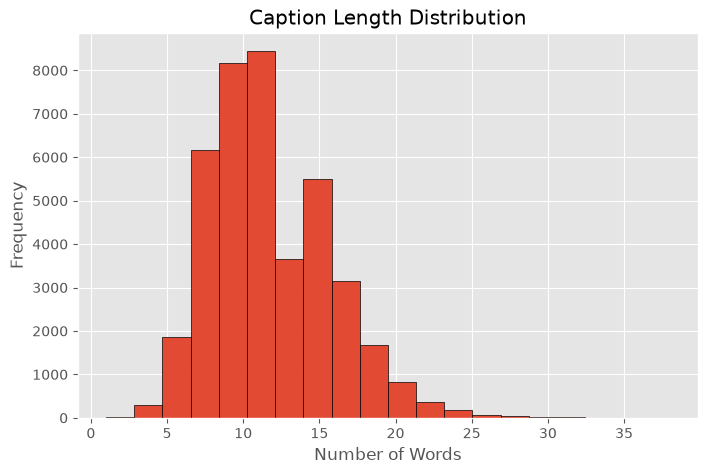

In [21]:
plt.figure(figsize=(8,5))

plt.hist(captions["caption_length"], bins=20, edgecolor="black")

plt.title("Caption Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [22]:
all_words = []

for caption in captions["caption_text"]:
    all_words.extend(str(caption).lower().split())

vocabulary = set(all_words)

print("Vocabulary Size:", len(vocabulary))

Vocabulary Size: 8918


In [23]:
from collections import Counter

word_counts = Counter(all_words)

common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

common_words

,Word,Frequency
0,a,62986
1,.,36577
2,in,18974
3,the,18418
4,on,10743
5,is,9345
6,and,8851
7,dog,8136
8,with,7765
9,man,7265


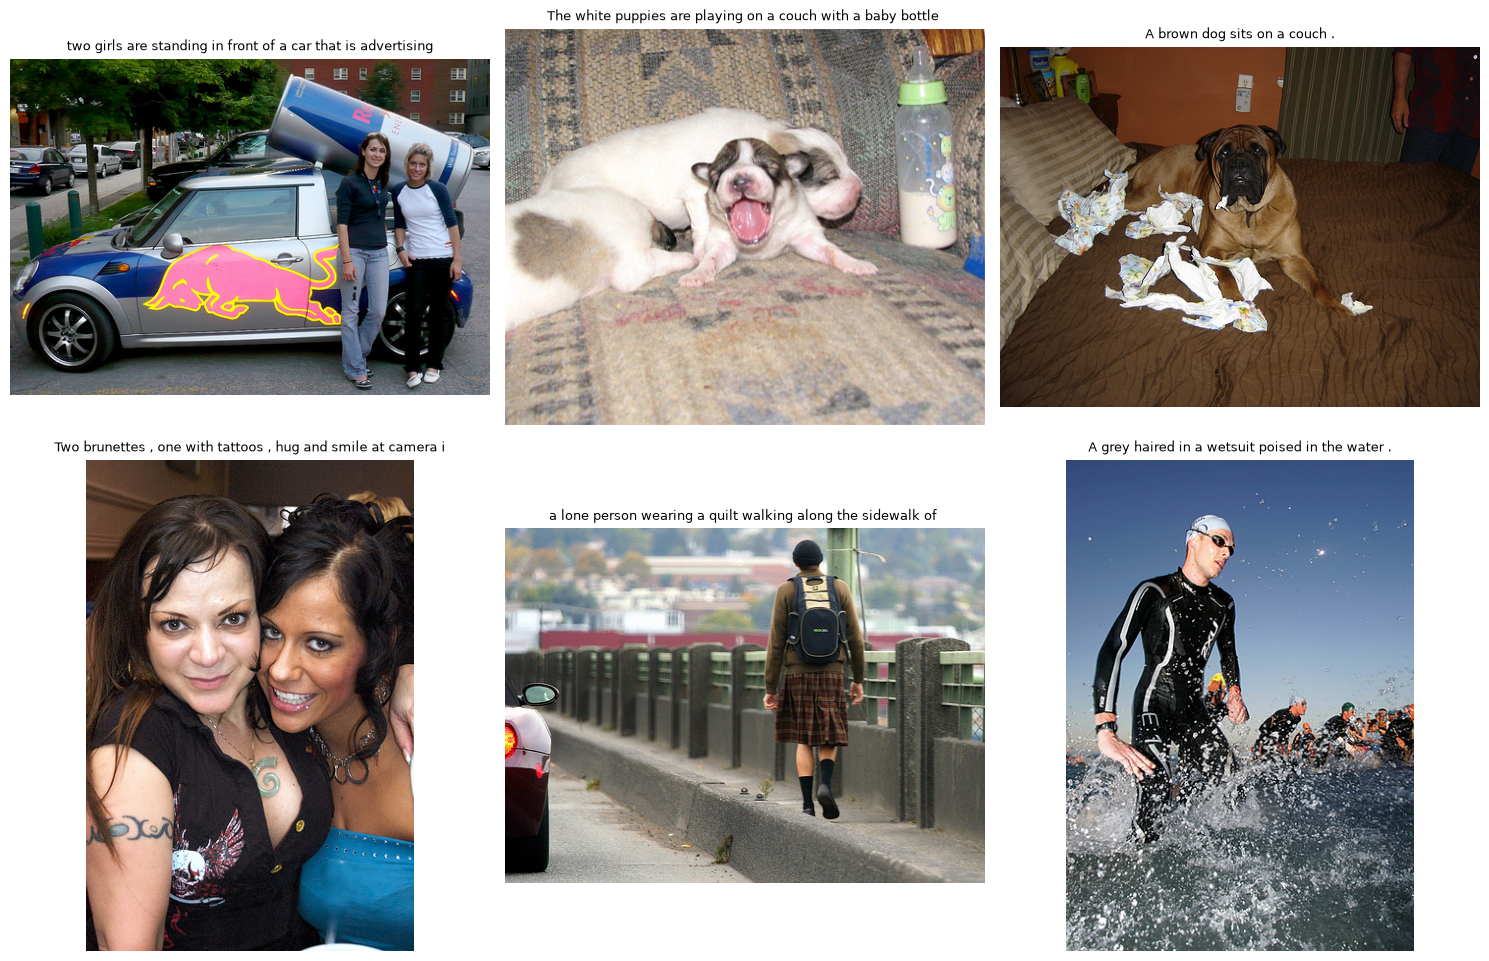

In [24]:
import random
from PIL import Image

sample_images = random.sample(list(captions["image_name"].unique()), 6)

fig, axes = plt.subplots(2, 3, figsize=(15,10))

for ax, img_name in zip(axes.flatten(), sample_images):

    img_path = os.path.join(image_folder, img_name)

    img = Image.open(img_path)

    caption = captions[captions["image_name"] == img_name]["caption_text"].iloc[0]

    ax.imshow(img)
    ax.set_title(caption[:60], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
duplicate_captions = captions.duplicated(subset=["caption_text"]).sum()

print("Duplicate Captions:", duplicate_captions)

Duplicate Captions: 254


In [26]:
blank_captions = captions["caption_text"].isnull().sum()

print("Blank Captions:", blank_captions)

Blank Captions: 0


In [27]:
short_captions = captions[captions["caption_length"] < 3]

print("Short Captions:", len(short_captions))

Short Captions: 17


In [30]:
from PIL import Image
import os

corrupted = []

for img in captions["image_name"].unique():
    img_path = os.path.join(image_folder, img)
    try:
        with Image.open(img_path) as im:
            im.verify()
    except Exception:
        corrupted.append(img)

print(f"Corrupted Images: {len(corrupted)}")

if len(corrupted) > 0:
    print(corrupted[:10])
else:
    print("No corrupted images found.")

Corrupted Images: 0
No corrupted images found.
